Dans ce TP, on essaye d'appliquer les différents concepts des statistiques descriptives sur le jeu de données tips

On commence par importer les bibliothèques dont on aura besoin

In [8]:
import matplotlib.pyplot as plt
import math as m
import pandas as pd
import numpy as np
import seaborn as sns
%matplotlib inline

Le jeu de donnée est accessible via le lien suivant : https://www.kaggle.com/datasets/aminizahra/tips-dataset

In [9]:
tips = pd.read_csv("tips.csv",header = 0, sep = ",")

Affichons tips

In [3]:
print(tips)

     total_bill   tip     sex smoker   day    time  size
0         16.99  1.01  Female     No   Sun  Dinner     2
1         10.34  1.66    Male     No   Sun  Dinner     3
2         21.01  3.50    Male     No   Sun  Dinner     3
3         23.68  3.31    Male     No   Sun  Dinner     2
4         24.59  3.61  Female     No   Sun  Dinner     4
..          ...   ...     ...    ...   ...     ...   ...
239       29.03  5.92    Male     No   Sat  Dinner     3
240       27.18  2.00  Female    Yes   Sat  Dinner     2
241       22.67  2.00    Male    Yes   Sat  Dinner     2
242       17.82  1.75    Male     No   Sat  Dinner     2
243       18.78  3.00  Female     No  Thur  Dinner     2

[244 rows x 7 columns]


In [5]:
type(tips)

pandas.core.frame.DataFrame

Dans un fichier Python (.py), écrire tips.shape seul ne suffira pas à afficher le résultat. Il faudra utiliser print(tips.shape)

In [4]:
tips.shape

(244, 7)

Des valeurs manquantes dans tips ?

In [4]:
tips.count()

total_bill    244
tip           244
sex           244
smoker        244
day           244
time          244
size          244
dtype: int64

Récapitulons avec info()

In [8]:
tips.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 244 entries, 0 to 243
Data columns (total 7 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   total_bill  244 non-null    float64
 1   tip         244 non-null    float64
 2   sex         244 non-null    object 
 3   smoker      244 non-null    object 
 4   day         244 non-null    object 
 5   time        244 non-null    object 
 6   size        244 non-null    int64  
dtypes: float64(2), int64(1), object(4)
memory usage: 13.5+ KB


Affichons les colonnes (Features)

In [9]:
list(tips.columns)
list(tips)

['total_bill', 'tip', 'sex', 'smoker', 'day', 'time', 'size']

##Analyse univariée

#Variable quantitative

Indicateurs basiques de tendance centrale et de dispersion

In [6]:
tips.describe()

,total_bill,tip,size
count,244.000000,244.000000,244.000000
mean,19.785943,2.998279,2.569672
std,8.902412,1.383638,0.951100
min,3.070000,1.000000,1.000000
25%,13.347500,2.000000,2.000000
50%,17.795000,2.900000,2.000000
75%,24.127500,3.562500,3.000000
max,50.810000,10.000000,6.000000


Pour plus de clarté : Arrondir les indicateurs 

In [7]:
tips.describe().round(2)

,total_bill,tip,size
count,244.00,244.00,244.00
mean,19.79,3.00,2.57
std,8.90,1.38,0.95
min,3.07,1.00,1.00
25%,13.35,2.00,2.00
50%,17.80,2.90,2.00
75%,24.13,3.56,3.00
max,50.81,10.00,6.00


Se contenter uniquement d'une seule variable quantitative

Les deux lignes accomplissent la même tâche

In [13]:
tips.total_bill.describe()
tips["total_bill"].describe()

count    244.000000
mean      19.785943
std        8.902412
min        3.070000
25%       13.347500
50%       17.795000
75%       24.127500
max       50.810000
Name: total_bill, dtype: float64

Calculer chaque indicateur d'une manière indépendante

In [7]:
tips.total_bill.mean()
tips.total_bill.std()
tips.total_bill.var()
tips.total_bill.min()
tips.total_bill.max()
tips.total_bill.median()
tips.total_bill.quantile(0.1)
tips.total_bill.quantile([0.1,0.5])

0.1    10.340
0.5    17.795
Name: total_bill, dtype: float64

Histogrammes confondus de l'ensemble des variables quantitatives (pas pratique si les variables ne possèdent pas la même unité)

<Axes: ylabel='Frequency'>

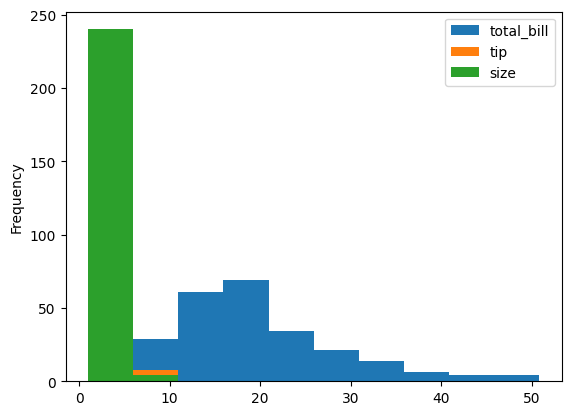

In [35]:
tips.plot.hist()

Histogramme propre à la variable quantitative "total_bill"

Text(0, 0.5, 'Nombre des factures')

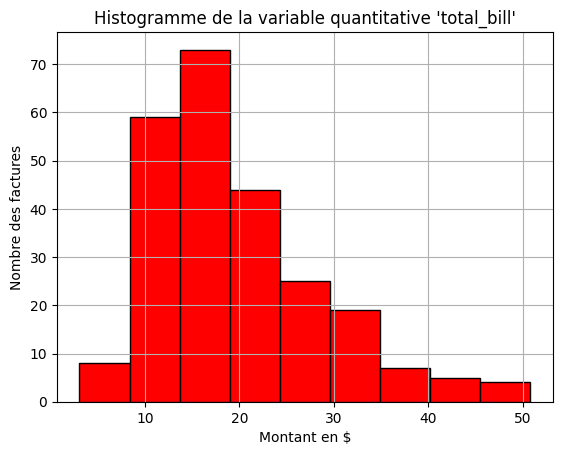

In [12]:
tips.total_bill.hist(color = 'red',edgecolor='black',bins = round(1+m.log2(len(tips))))
plt.title("Histogramme de la variable quantitative 'total_bill'")
plt.xlabel('Montant en $')
plt.ylabel('Nombre des factures')

Critère de Sturges

In [13]:
bins = round(1+m.log2(len(tips)))
print(bins)

9


Boite à moustache des variables quantitatives

Text(0, 0.5, 'Valeur')

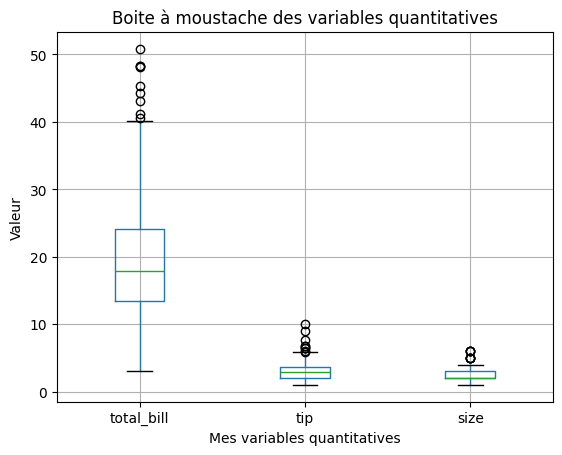

In [15]:
tips.boxplot()
plt.title("Boite à moustache des variables quantitatives")
plt.xlabel('Mes variables quantitatives')
plt.ylabel('Valeur')

Boite à moustache de variables quantitatives ayant la même unité de mesure ($)

Text(0, 0.5, 'Montant en $')

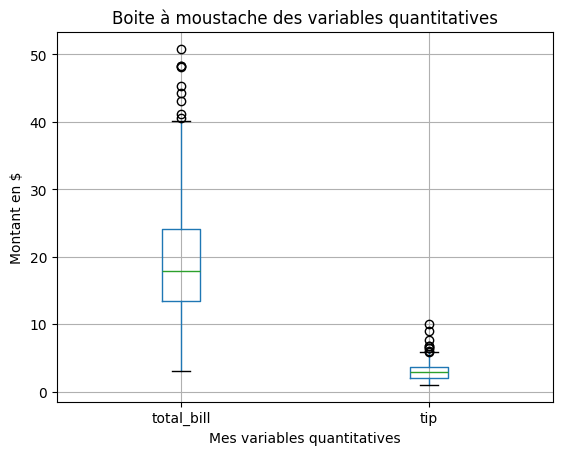

In [16]:
tips.drop('size',axis=1).boxplot()
plt.title("Boite à moustache des variables quantitatives")
plt.xlabel('Mes variables quantitatives')
plt.ylabel('Montant en $')

Boite à moustache d'une seule variable quantitative 'total_bill'

<Axes: >

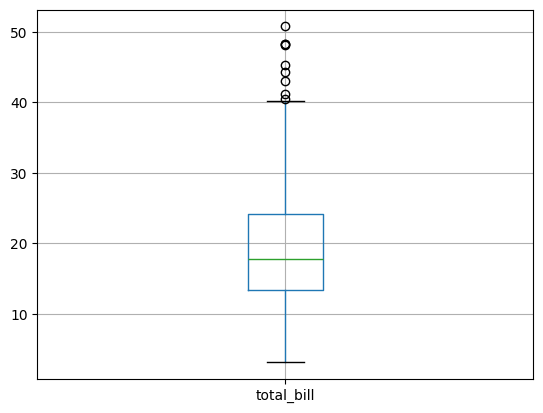

In [17]:
tips.boxplot(column = "total_bill")

Une deuxième méthode pour réaliser un histogramme (kind est riche de graphiques)

Text(0, 0.5, 'Nombre des factures')

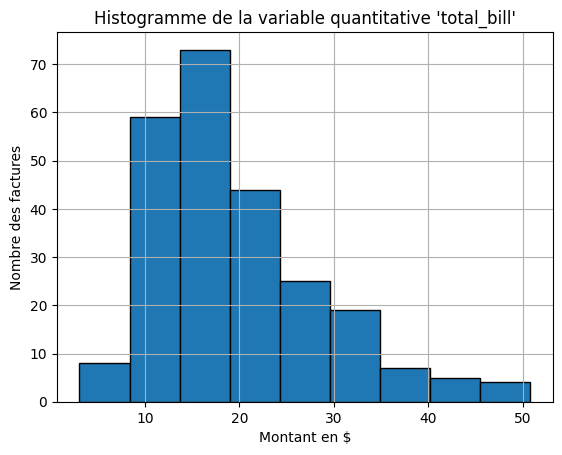

In [22]:
tips.total_bill.plot(kind = 'hist',grid = True, edgecolor = 'black', bins = round(1+m.log2(len(tips))))
plt.title("Histogramme de la variable quantitative 'total_bill'")
plt.xlabel('Montant en $')
plt.ylabel('Nombre des factures')

Même histogramme avec density = True
L'aire totale de l'histogramme est égale à 1. Cela permet d'interpréter l'histogramme comme une estimation de la fonction de densité de probabilité (à voir dans la suite du cours)

Text(0, 0.5, 'Nombre des factures')

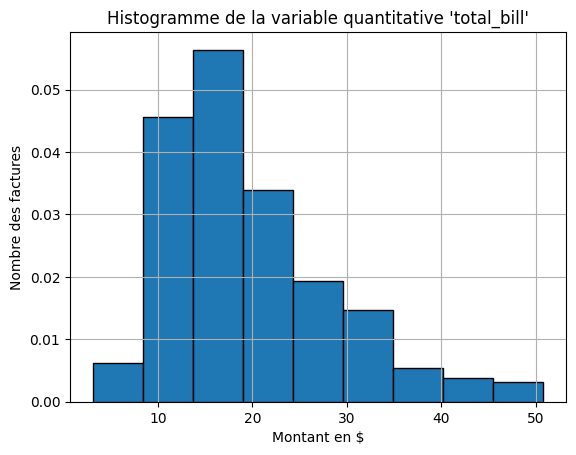

In [23]:
tips.total_bill.plot(kind = 'hist',density = True, grid = True, edgecolor = 'black', bins = round(1+m.log2(len(tips))))
plt.title("Histogramme de la variable quantitative 'total_bill'")
plt.xlabel('Montant en $')
plt.ylabel('Nombre des factures')

#Variable qualitative

Fréquence des modalités d'une variable qualitative (catégorielle)

In [26]:
tips.sex.describe()

count      244
unique       2
top       Male
freq       157
Name: sex, dtype: object

Recensement des modalités d'une variable qualitative

In [27]:
tips.sex.unique()

array(['Female', 'Male'], dtype=object)

In [28]:
tips.sex.value_counts()

sex
Male      157
Female     87
Name: count, dtype: int64

In [29]:
tips.time.value_counts()

time
Dinner    176
Lunch      68
Name: count, dtype: int64

In [36]:
pd.crosstab(tips.sex, "freq")

col_0,freq
sex,
Female,87
Male,157


In [37]:
pd.crosstab(tips.sex, "freq", normalize=True)

col_0,freq
sex,
Female,0.356557
Male,0.643443


Diagramme en batons de la variable qualitative 'smoker'

Text(0, 0.5, 'Effectif')

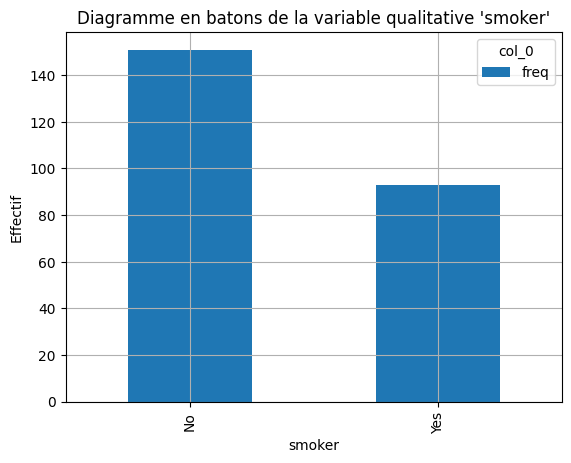

In [34]:
t = pd.crosstab(tips.smoker, "freq")
t.plot.bar(grid = True)
plt.title("Diagramme en batons de la variable qualitative 'smoker'")
plt.ylabel('Effectif')

Pie-chart de la variable smoker

array([<Axes: ylabel='freq'>], dtype=object)

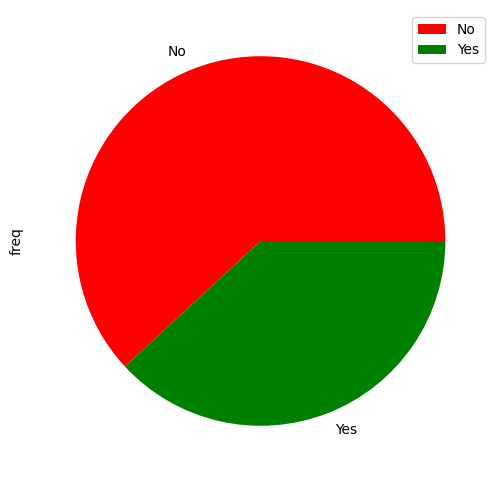

In [35]:
t.plot.pie(subplots=True, figsize = (6, 6),colors=['red','green'])

#Variable qualitative - Variable quantitative

Moyenne des variables quantitatives par modalité de la variable qualitative 'smoker'

In [59]:
tips.select_dtypes(include=['number']).groupby(tips.smoker).mean()

,total_bill,tip,size
smoker,,,
No,19.188278,2.991854,2.668874
Yes,20.756344,3.008710,2.408602


Statistiques descriptives de la variable 'total_bill' selon les modalités de la variable 'sex'

In [62]:
tips.groupby("sex")["total_bill"].agg([np.mean, np.std, np.median, np.min, np.max,np.ptp])

C:\Users\PRIMERO\AppData\Local\Temp\ipykernel_12380\1155381947.py:1: FutureWarning: The provided callable <function mean at 0x0000014EC8666D40> is currently using SeriesGroupBy.mean. In a future version of pandas, the provided callable will be used directly. To keep current behavior pass the string "mean" instead.
  tips.groupby("sex")["total_bill"].agg([np.mean, np.std, np.median, np.min, np.max,np.ptp])
C:\Users\PRIMERO\AppData\Local\Temp\ipykernel_12380\1155381947.py:1: FutureWarning: The provided callable <function std at 0x0000014EC8666E80> is currently using SeriesGroupBy.std. In a future version of pandas, the provided callable will be used directly. To keep current behavior pass the string "std" instead.
  tips.groupby("sex")["total_bill"].agg([np.mean, np.std, np.median, np.min, np.max,np.ptp])
C:\Users\PRIMERO\AppData\Local\Temp\ipykernel_12380\1155381947.py:1: FutureWarning: The provided callable <function median at 0x0000014EC8792AC0> is currently using SeriesGroupBy.median

,mean,std,median,min,max,ptp
sex,,,,,,
Female,18.056897,8.009209,16.40,3.07,44.30,41.23
Male,20.744076,9.246469,18.35,7.25,50.81,43.56


Histogramme de la variable 'tip' avec une agrégation des données selon la variable 'sex'

Text(0, 0.5, 'Fréquence')

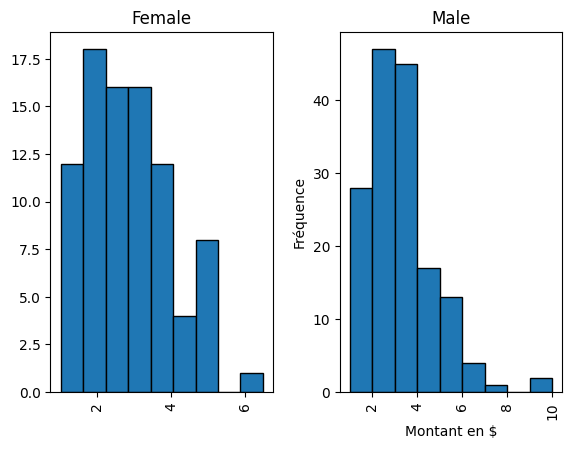

In [14]:
tips.tip.hist(by = tips.sex, bins =round(1+m.log2(len(tips))),edgecolor='black')
#plt.title("Histogramme de la variable quantitative 'total_bill'")
plt.xlabel('Montant en $')
plt.ylabel('Fréquence')

Boxplot de la variable 'tip' avec une agrégation des données selon la variable 'time'

Text(0, 0.5, 'Montant en $')

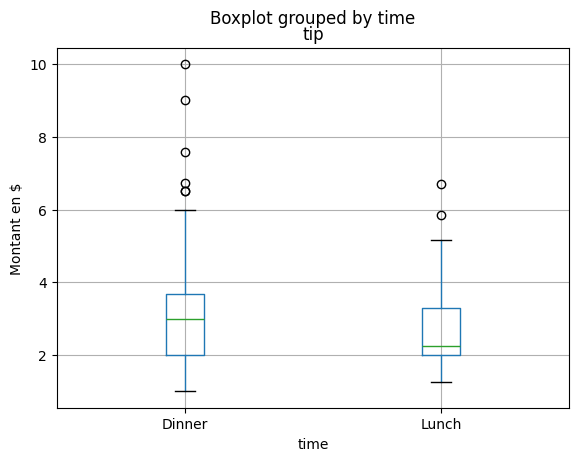

In [16]:
tips.boxplot(column = "tip",by = 'time')
plt.ylabel('Montant en $')

Boxplot de la variable 'tip' avec une agrégation des données selon la variable 'sex'

<Axes: title={'center': 'tip'}, xlabel='sex'>

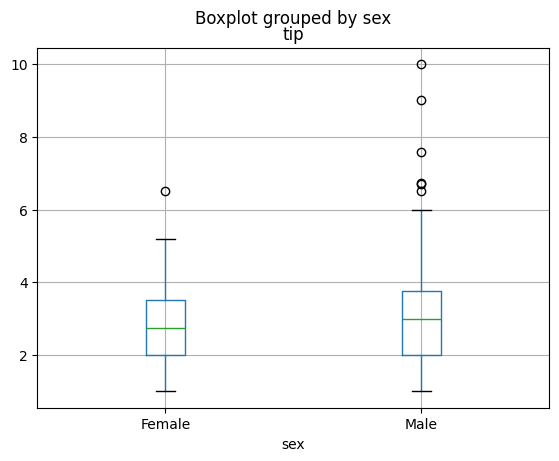

In [61]:
tips.boxplot( column = "tip",by = "sex")

#Variable quantitative - Variable quantitative

Matrice de corrélation

In [37]:
tips[['total_bill','tip','size']].corr()

,total_bill,tip,size
total_bill,1.000000,0.675734,0.598315
tip,0.675734,1.000000,0.489299
size,0.598315,0.489299,1.000000


Deuxième méthode (Via la spécification des variables quantitatives)

In [40]:
numeric_columns = tips.select_dtypes(include=['number']).columns
correlation_matrix = tips[['total_bill','tip','size']].corr()
print(correlation_matrix)

            total_bill       tip      size
total_bill    1.000000  0.675734  0.598315
tip           0.675734  1.000000  0.489299
size          0.598315  0.489299  1.000000


Correlation Heatmap : Une carte de chaleur de corrélation est un outil graphique qui affiche la corrélation entre plusieurs variables sous la forme d'une matrice codée par couleurs.

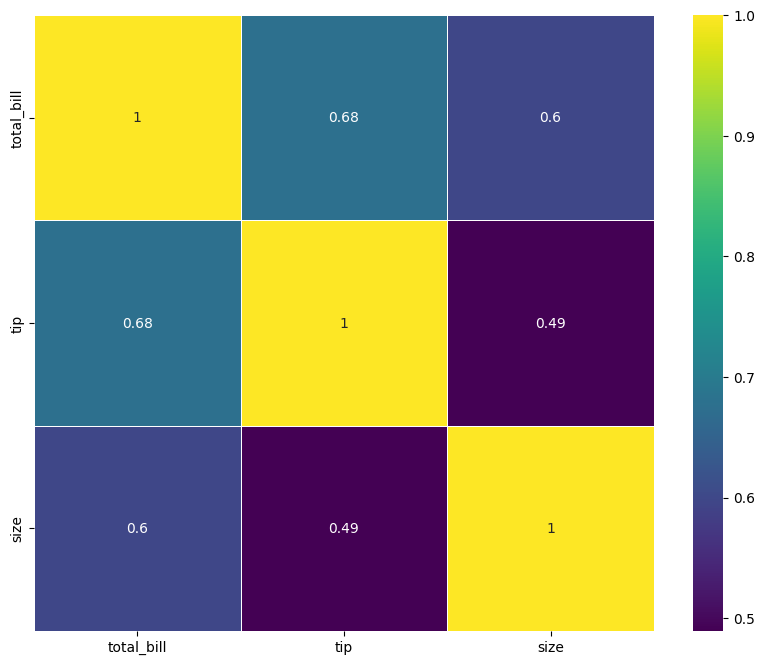

In [44]:
plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='viridis', linewidths=0.5)
plt.show()

Profiter du fait qua la matrice de corrélation est une matrice symétrique 

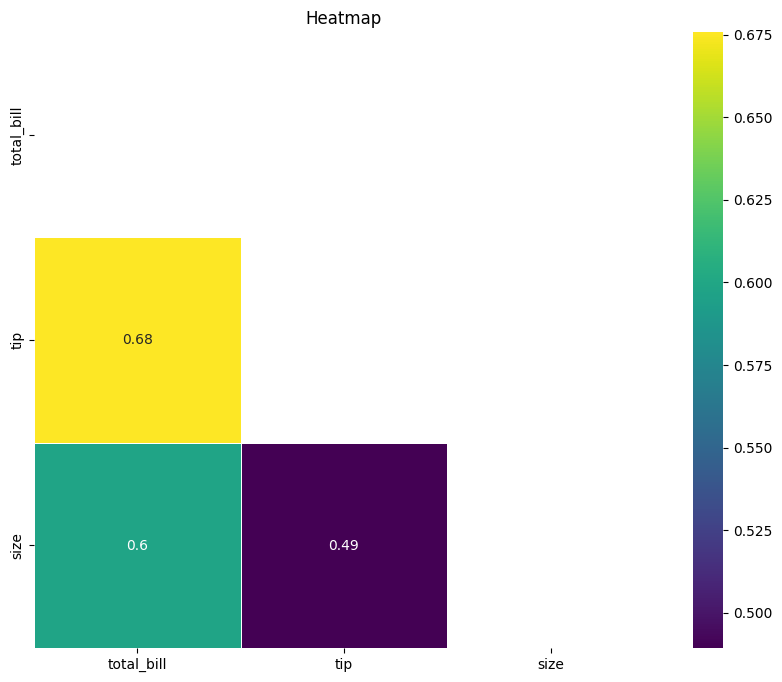

In [43]:
plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='viridis', linewidths=0.5,mask= np.triu(np.ones_like(correlation_matrix, dtype=bool)))
plt.title("Heatmap")
plt.show()

Nuage de points (Scatter plot)

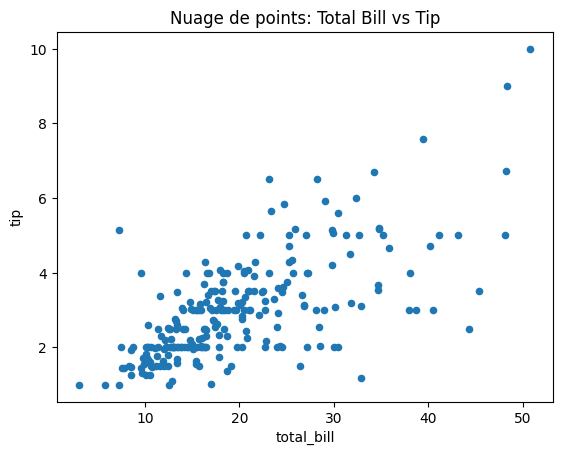

In [58]:
tips.plot(kind='scatter', x='total_bill', y='tip')
plt.title('Nuage de points: Total Bill vs Tip')
plt.show()

La corrélation entre deux variables quantitatives

In [39]:
tips.total_bill.corr(tips.tip)

0.6757341092113645

La covariance entre deux variables quantitatives

In [45]:
tips.total_bill.cov(tips.tip)

8.323501629224854

La corrélation d'une manière plus détaillée

In [46]:
tips.total_bill.cov(tips.tip)/(tips.total_bill.std()*tips.tip.std())

0.6757341092113646

Matrice de scatter plots
La diagonale est composée des histogrammes 

array([[<Axes: xlabel='total_bill', ylabel='total_bill'>,
        <Axes: xlabel='tip', ylabel='total_bill'>,
        <Axes: xlabel='size', ylabel='total_bill'>],
       [<Axes: xlabel='total_bill', ylabel='tip'>,
        <Axes: xlabel='tip', ylabel='tip'>,
        <Axes: xlabel='size', ylabel='tip'>],
       [<Axes: xlabel='total_bill', ylabel='size'>,
        <Axes: xlabel='tip', ylabel='size'>,
        <Axes: xlabel='size', ylabel='size'>]], dtype=object)

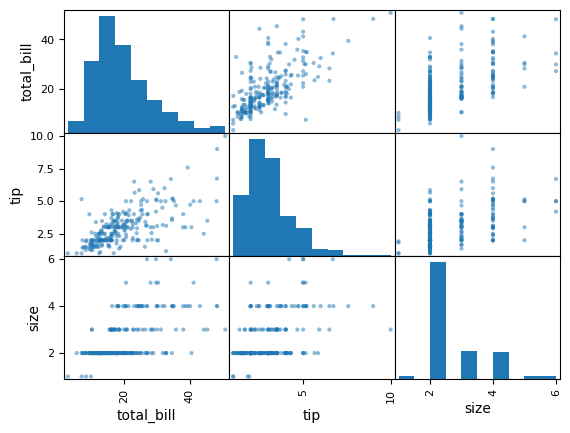

In [47]:
pd.plotting.scatter_matrix(tips)

#Variable qualitative - Variable qualitative

In [48]:
pd.crosstab(tips.sex, tips.smoker)

smoker,No,Yes
sex,,
Female,54,33
Male,97,60


In [49]:
pd.crosstab(tips.sex, tips.smoker, margins=True)

smoker,No,Yes,All
sex,,,
Female,54,33,87
Male,97,60,157
All,151,93,244


In [50]:
pd.crosstab(tips.sex, tips.smoker, normalize = True)

smoker,No,Yes
sex,,
Female,0.221311,0.135246
Male,0.397541,0.245902


In [51]:
pd.crosstab(tips.sex, tips.smoker, normalize = "index")

smoker,No,Yes
sex,,
Female,0.620690,0.379310
Male,0.617834,0.382166


In [52]:
pd.crosstab(tips.sex, tips.smoker, normalize = "index", margins=True)

smoker,No,Yes
sex,,
Female,0.620690,0.379310
Male,0.617834,0.382166
All,0.618852,0.381148


In [53]:
pd.crosstab(tips.sex, tips.smoker, normalize = True, margins=True)

smoker,No,Yes,All
sex,,,
Female,0.221311,0.135246,0.356557
Male,0.397541,0.245902,0.643443
All,0.618852,0.381148,1.000000


In [54]:
pd.crosstab(tips.sex, tips.smoker, normalize = "columns")

smoker,No,Yes
sex,,
Female,0.357616,0.354839
Male,0.642384,0.645161


In [55]:
pd.crosstab(tips.sex, tips.smoker, normalize = "columns", margins=True)

smoker,No,Yes,All
sex,,,
Female,0.357616,0.354839,0.356557
Male,0.642384,0.645161,0.643443


Diagramme en batons esquivés des modalités de deux variables qualitatives

Text(0, 0.5, 'effectifs')

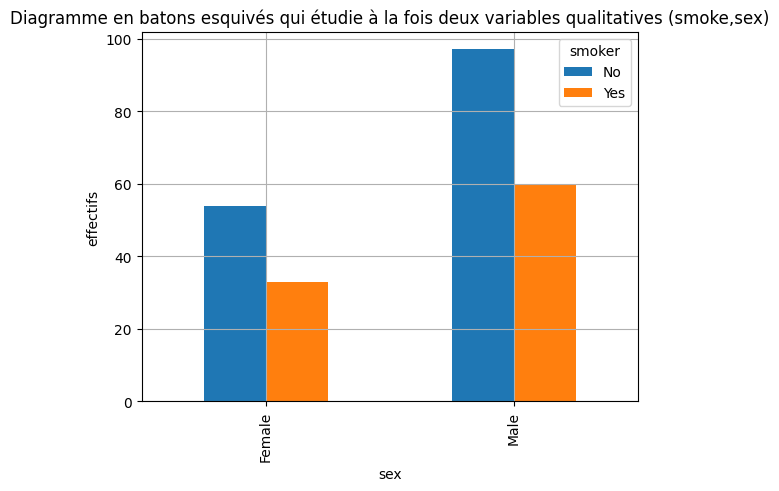

In [56]:
t = pd.crosstab(tips.sex, tips.smoker)
t.plot.bar(grid=True)
plt.title("Diagramme en batons esquivés qui étudie à la fois deux variables qualitatives (smoke,sex)")
plt.ylabel("effectifs")

Diagramme en batons empilés des modalités de deux variables qualitatives

Text(0, 0.5, 'effectifs')

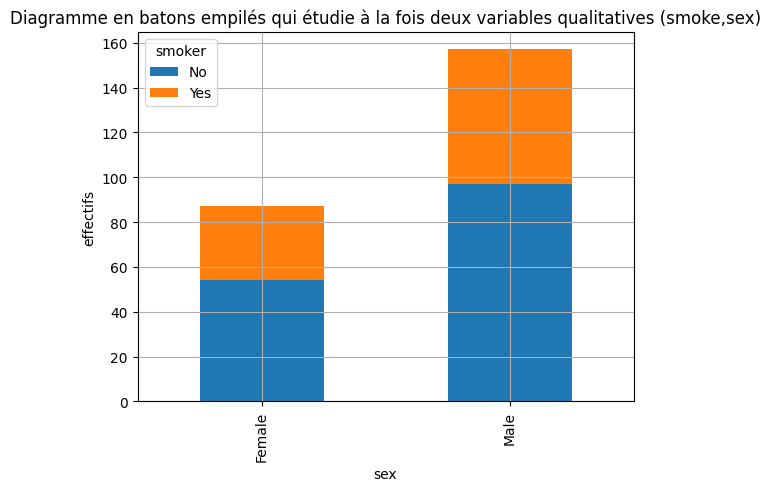

In [57]:
t = pd.crosstab(tips.sex, tips.smoker)
t.plot.bar(stacked=True, grid = True)
plt.title("Diagramme en batons empilés qui étudie à la fois deux variables qualitatives (smoke,sex)")
plt.ylabel("effectifs")

Diagrammes circulaires selon les modalités de deux variables qualitatives

array([<Axes: ylabel='No'>, <Axes: ylabel='Yes'>], dtype=object)

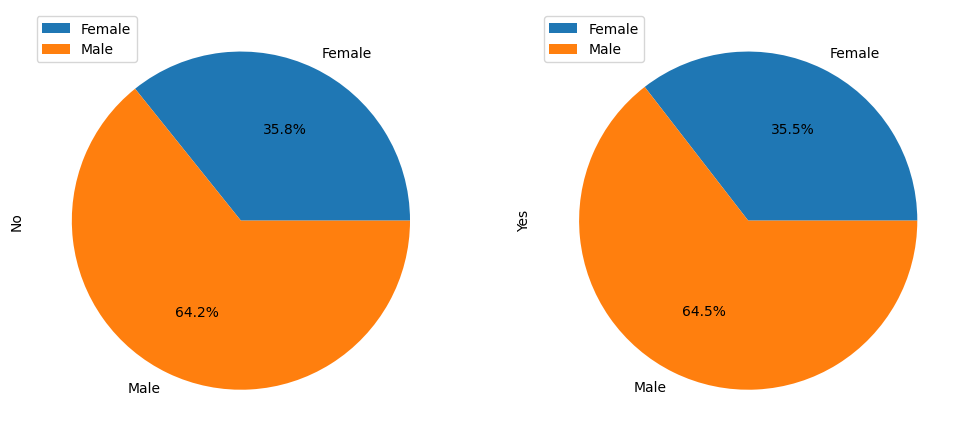

In [58]:
t = pd.crosstab(tips.sex, tips.smoker)
t.plot.pie(subplots=True,autopct = '%1.1f%%',figsize = (12, 6))